In [1]:
import numpy as np

import matplotlib.pyplot as plt

import jax

import jax.numpy as jnp

from jax import jit, vmap

import torch
import torch.nn as nn
import torch.optim as optim

from collections import deque
import random

from flax import linen as nn
from flax.training import train_state
import optax


In [2]:
class Maze:
    def __init__(self, maze, start_position, goal_position):
        self.maze = maze
        self.start_position = jnp.array(start_position)
        self.goal_position = jnp.array(goal_position)
        self.reset()

    def reset(self):
        self.current_position = self.start_position
        return self.current_position

    def step(self, action):
        # JAX不允许在原地修改数组，因此我们将位置作为不可变的jnp数组处理
        next_position = self.current_position

        next_position, reward, done = self.step_cal(action, next_position, self.goal_position, self.maze.shape[1], self.maze.shape[0], self.maze[next_position[1], next_position[0]])

        self.current_position = next_position

        return self.current_position, reward, done

    @staticmethod
    @jit
    def step_cal(action, next_position, goal_position, shape_1, shape_0, wall_position_value):
        next_position = jax.lax.cond(action == 0, lambda x: x.at[1].add(-1), lambda x: x, next_position)  # up
        next_position = jax.lax.cond(action == 1, lambda x: x.at[1].add(1), lambda x: x, next_position)   # down
        next_position = jax.lax.cond(action == 2, lambda x: x.at[0].add(-1), lambda x: x, next_position)  # left
        next_position = jax.lax.cond(action == 3, lambda x: x.at[0].add(1), lambda x: x, next_position)   # right

        # 检查是否在迷宫边界内
        within_bounds = (0 <= next_position[0]) & (next_position[0] < shape_1) & \
                        (0 <= next_position[1]) & (next_position[1] < shape_0)

        # 检查是否撞墙
        not_wall = jax.lax.cond(within_bounds,
                                lambda _: wall_position_value == 0,
                                lambda _: False, None)

        # 更新当前位置，如果满足条件
        next_position = jax.lax.cond(not_wall, lambda _: next_position, lambda _: next_position, None)

        done = jnp.array_equal(next_position, goal_position)
        reward = jax.lax.cond(done, lambda _: 1.0, lambda _: -0.1, None)

        return next_position, reward, done
    def render(self):
        maze_copy = self.maze.copy()
        maze_copy = maze_copy.at[self.current_position[1], self.current_position[0]].set(2)
        plt.figure(figsize=(5, 5))
        plt.imshow(maze_copy, cmap='gray')

        plt.text(self.start_position[0], self.start_position[1], 'S', ha='center', va='center', color='red', fontsize=20)
        plt.text(self.goal_position[0], self.goal_position[1], 'G', ha='center', va='center', color='green', fontsize=20)

        plt.show()


In [19]:
class DQN(nn.Module):
    action_size: int

    @nn.compact
    def __call__(self, x):
        x = nn.relu(nn.Dense(24)(x))
        x = nn.relu(nn.Dense(24)(x))
        return nn.Dense(self.action_size)(x)


class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95  # discount rate
        self.epsilon = 1.0  # exploration rate
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.key = jax.random.PRNGKey(0)

        # Initialize DQN model and optimizer
        self.model = DQN(action_size=self.action_size)
        self.params = self.model.init(self.key, jnp.ones((1, state_size)))
        self.optimizer = optax.adam(self.learning_rate)
        self.state = train_state.TrainState.create(apply_fn=self.model.apply, params=self.params, tx=self.optimizer)

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = jnp.array(state).reshape(1, -1)
        q_values = self.state.apply_fn({'params': self.state.params['params']}, state)
        return int(jnp.argmax(q_values))


    def compute_loss(self, params, state, target):
        q_values = self.model.apply({'params': params['params']}, state)
        loss = jnp.mean((q_values - target) ** 2)
        return loss

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return

        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            state = jnp.array(state).reshape(1, -1)
            next_state = jnp.array(next_state).reshape(1, -1)

            target = reward
            if not done:
                next_q_values = self.state.apply_fn(self.state.params, next_state)
                target = reward + self.gamma * jnp.max(next_q_values)

            target_f = self.state.apply_fn( self.state.params, state)
            target_f = target_f.at[0, action].set(target)

            # Compute gradients and update weights
            grad_fn = jax.value_and_grad(self.compute_loss)
            loss, grads = grad_fn(self.state.params, state, target_f)
            self.state = self.state.apply_gradients(grads=grads)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

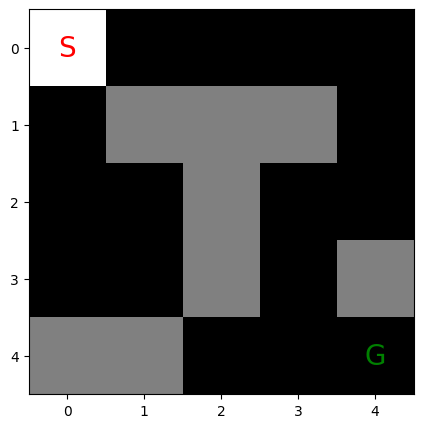

KeyboardInterrupt: 

In [20]:
maze_layout = jnp.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 1],
    [1, 1, 0, 0, 0]
])

maze = Maze(maze_layout, (0, 0), (4, 4))
maze.render()

if __name__ == "__main__":
    env = Maze(maze_layout, (0, 0), (4, 4))
    state_size = 2  # x and y position
    action_size = 4  # up, down, left, right
    agent = DQNAgent(state_size, action_size)
    episodes = 200
    batch_size = 32

    for e in range(episodes):
        state = env.reset()
        for time in range(500):
            action = agent.act(state)
            next_state, reward, done = env.step(action)
            agent.remember(state, action, reward, next_state, done)
            state = next_state
            if done:
                print(f"Episode {e+1}/{episodes} finished after {time+1} timesteps")
                break
            if len(agent.memory) > batch_size:
                agent.replay(batch_size)
        if e % 50 == 0:
            env.render()


In [ ]:
def test_agent(env, agent, episodes=5):
    success_count = 0
    test_steps = []
    for e in range(episodes):
        state = env.reset()
        steps = 0
        for time in range(100):
            action = agent.act(state)
            next_state, reward, done = env.step(action)
            state = next_state
            steps += 1
            if done:
                test_steps.append(steps)
                success_count += 1
                print(f"Test Episode {e+1}/{episodes} succeeded after {time+1} timesteps")
                break
        # env.render()
    print(f"Agent succeeded in {success_count}/{episodes} test episodes.")
    print("Test Steps:", test_steps)


# Testing the trained agent
test_agent(env, agent)


Test Episode 1/5 succeeded after 10 timesteps
Test Episode 2/5 succeeded after 10 timesteps
Test Episode 3/5 succeeded after 12 timesteps
Test Episode 4/5 succeeded after 10 timesteps
Test Episode 5/5 succeeded after 10 timesteps
Agent succeeded in 5/5 test episodes.
Test Steps: [10, 10, 12, 10, 10]
